In [1]:
!pip install matplotlib seaborn scikit-learn lightgbm xgboost catboost shap -i https://pypi.tuna.tsinghua.edu.cn/simple

Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple


训练集形状： (8000, 9)
测试集形状： (2000, 8)
  Ship_Type  Gross_Tonnage Years_In_Service  Voyage_Distance Port_Of_Origin  \
0       散货船         228997            5-10年             1878           鹿特丹港   
1        邮轮         127417           10-15年              783           新加坡港   
2        油轮         117585            5-10年             9571           新加坡港   
3       散货船          31346             1-3年            10586           新加坡港   
4      集装箱船         220356              <1年             2110            釜山港   

  Arrival_Term  Wind_Speed  Visibility  Delay_Risk  
0           高峰         5.9         9.2           1  
1           平峰         0.7         7.0           0  
2           平峰        13.5         3.5           1  
3           高峰        11.9         1.3           0  
4           高峰        11.9         9.3           0  
===== 船舶靠泊延误风险分布 =====
Delay_Risk
1    4100
0    3900
Name: count, dtype: int64
延误占比： 0.5125


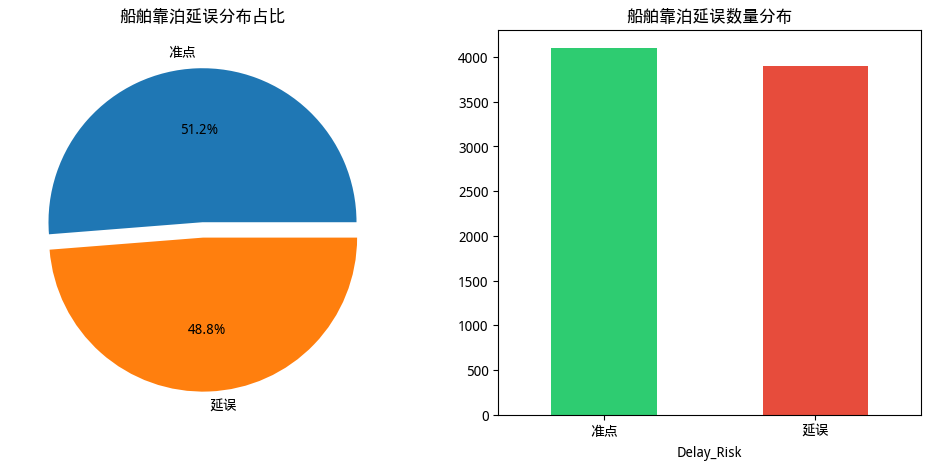

===== 训练集缺失值统计 =====
Ship_Type           0
Gross_Tonnage       0
Years_In_Service    0
Voyage_Distance     0
Port_Of_Origin      0
Arrival_Term        0
Wind_Speed          0
Visibility          0
Delay_Risk          0
dtype: int64


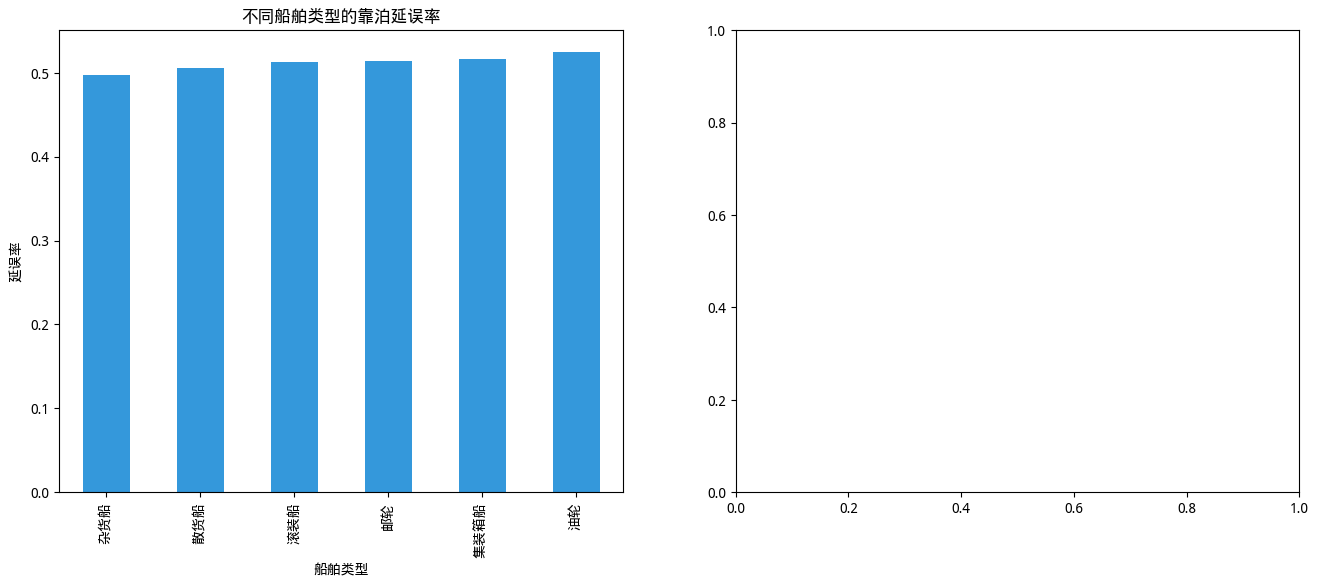

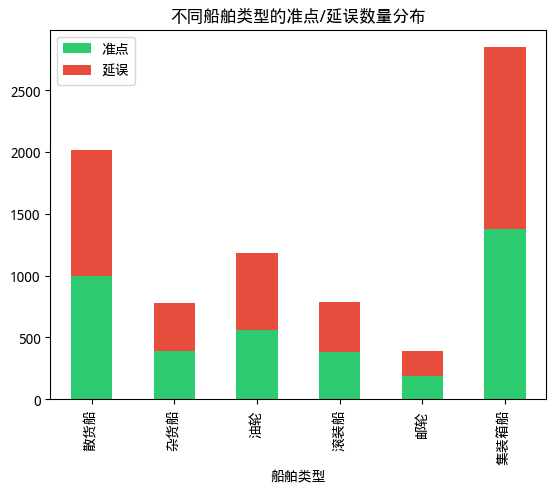

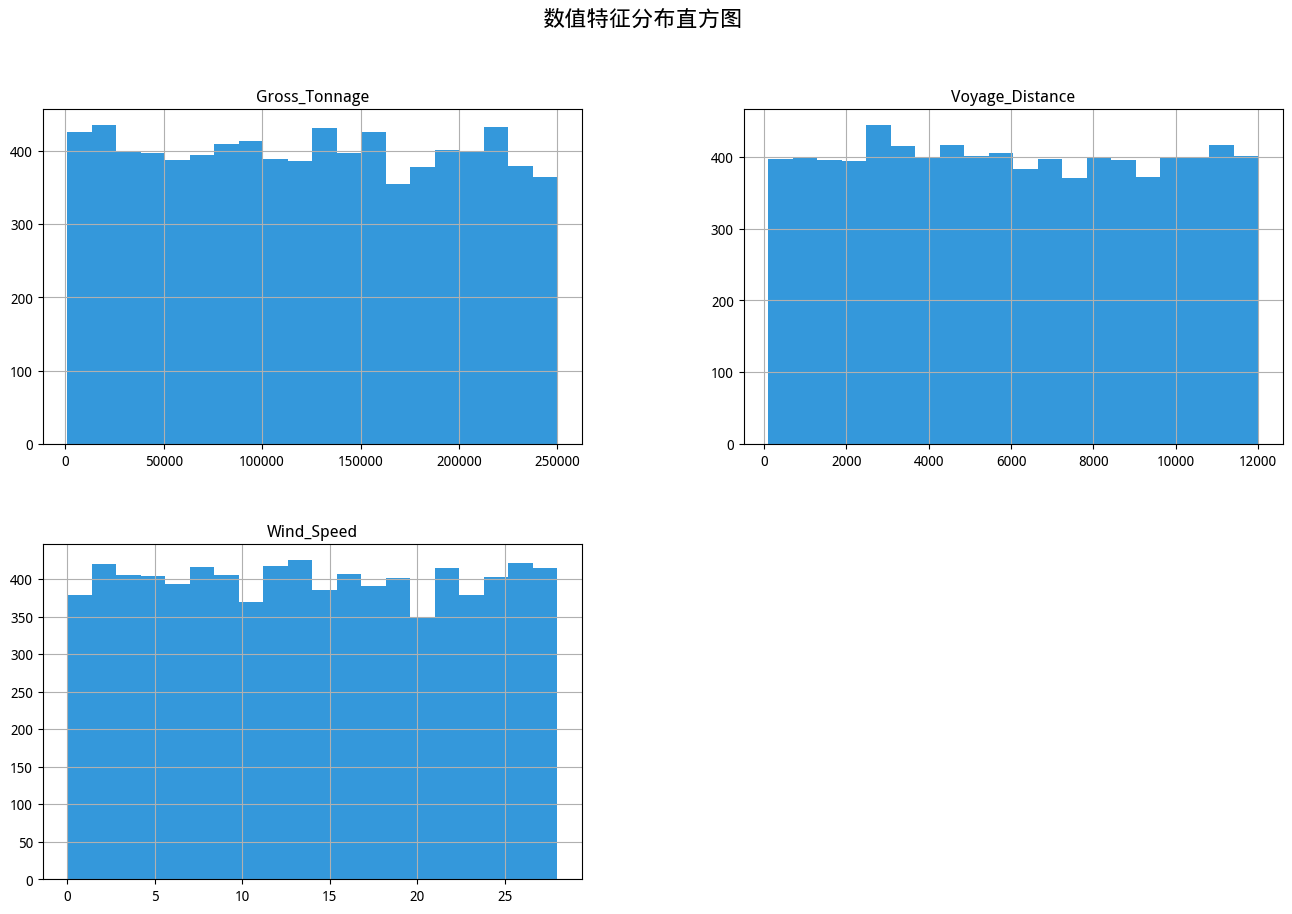

===== 训练模型：LR =====
LR 5折平均F1：0.6864
===== 训练模型：SVM =====
SVM 5折平均F1：0.6787
===== 训练模型：DT =====
DT 5折平均F1：0.6777
===== 训练模型：RF =====
RF 5折平均F1：0.6845
===== 训练模型：GBDT =====
GBDT 5折平均F1：0.6928
===== 训练模型：NB =====
NB 5折平均F1：0.6859
===== 训练模型：MLP =====
MLP 5折平均F1：0.6792
===== 训练模型：LGB =====
LGB 5折平均F1：0.6878
===== 训练模型：XGB =====
XGB 5折平均F1：0.6835
===== 训练模型：CAT =====
CAT 5折平均F1：0.6916
===== 所有模型F1表现 =====
GBDT: 0.6928
CAT: 0.6916
LGB: 0.6878
LR: 0.6864
NB: 0.6859
RF: 0.6845
XGB: 0.6835
MLP: 0.6792
SVM: 0.6787
DT: 0.6777
最佳模型：GBDT，最佳F1：0.6928


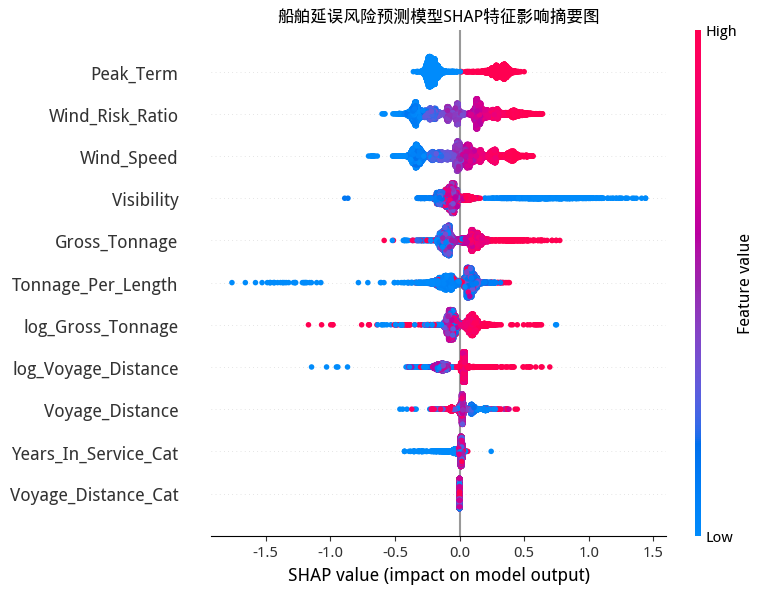

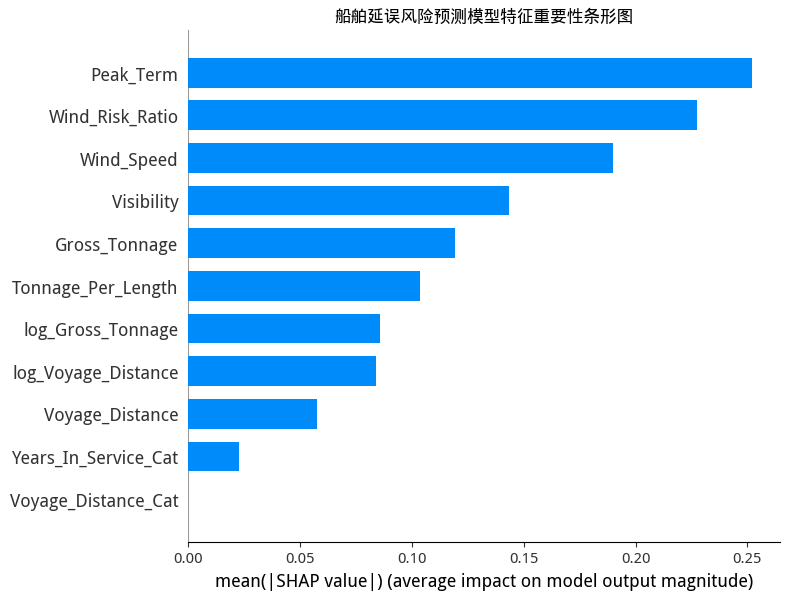

===== 模型融合权重分配 =====
GBDT: 0.1035
CAT: 0.1030
LGB: 0.1013
LR: 0.1007
NB: 0.1005
RF: 0.0998
XGB: 0.0994
MLP: 0.0975
SVM: 0.0973
DT: 0.0969
加权融合模型最佳F1：0.6820，最佳阈值：0.2851
提交文件生成完成！


In [2]:
# ====================== 全局配置：中文显示+关闭警告（只执行一次）======================
import matplotlib.pyplot as plt
import matplotlib as mpl
# 全局统一设置中文字体，彻底解决方框乱码和findfont报错
plt.rcParams['font.sans-serif'] = ['WenQuanYi Micro Hei', 'WenQuanYi Zen Hei', 'DejaVu Sans']
mpl.rcParams['font.sans-serif'] = ['WenQuanYi Micro Hei', 'WenQuanYi Zen Hei', 'DejaVu Sans']
# 解决负号显示成方框的问题
plt.rcParams['axes.unicode_minus'] = False
mpl.rcParams['axes.unicode_minus'] = False
# 全局关闭所有无关警告，包括findfont字体警告
import warnings
warnings.filterwarnings('ignore')

# ====================== 导入所有依赖库（只导入一次，不要重复导入）======================
import pandas as pd
import numpy as np
import seaborn as sns

# ===================== 第二部分：读取数据=====================
# 训练集、测试集路径
TRAIN_PATH = "train.csv"
TEST_PATH = "test.csv"
SUBMISSION_PATH = "sample_submission.csv"

# 读取数据
train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)
submission = pd.read_csv(SUBMISSION_PATH)

# 查看数据全貌
print("训练集形状：", train.shape)
print("测试集形状：", test.shape)
print(train.head())

# ===================== 第三部分：EDA分析=====================
# 1. 查看标签分布（船舶延误风险分布）
print("===== 船舶靠泊延误风险分布 =====")
print(train['Delay_Risk'].value_counts())
print("延误占比：", train['Delay_Risk'].mean())

# 可视化标签分布
plt.figure(figsize=(12, 5))
plt.subplot(1,2,1)
train['Delay_Risk'].value_counts().plot.pie(autopct='%.1f%%', labels=['准点', '延误'], explode=[0, 0.1])
plt.title('船舶靠泊延误分布占比')
plt.subplot(1,2,2)
train['Delay_Risk'].value_counts().plot.bar(color=['#2ecc71', '#e74c3c'])
plt.title('船舶靠泊延误数量分布')
plt.xticks([0,1], ['准点', '延误'], rotation=0)
plt.savefig('label_dist.png', dpi=300, bbox_inches='tight')
plt.show()

# 2. 缺失值统计
print("===== 训练集缺失值统计 =====")
print(train.isnull().sum().sort_values(ascending=False))

# 3. 类别特征与延误风险的关系分析
# 以船舶类型Ship_Type为例
plt.figure(figsize=(16, 6))
# 左图：不同船舶类型的延误率
plt.subplot(1,2,1)
ship_delay = train.groupby('Ship_Type')['Delay_Risk'].mean().sort_values()
ship_delay.plot.bar(color='#3498db')
plt.title('不同船舶类型的靠泊延误率')
plt.ylabel('延误率')
plt.xlabel('船舶类型')
# 右图：不同船舶类型的样本量
plt.subplot(1,2,2)
ship_count = train.groupby('Ship_Type')['Delay_Risk'].value_counts().unstack()
ship_count.plot.bar(stacked=True, color=['#2ecc71', '#e74c3c'])
plt.title('不同船舶类型的准点/延误数量分布')
plt.xlabel('船舶类型')
plt.legend(['准点', '延误'])
plt.savefig('ship_type_eda.png', dpi=300, bbox_inches='tight')
plt.show()

# 4. 数值特征分布分析
num_features = ['Gross_Tonnage', 'Voyage_Distance', 'Wind_Speed', 'Years_In_Service']
train[num_features].hist(figsize=(16, 10), bins=20, color='#3498db')
plt.suptitle('数值特征分布直方图', fontsize=16)
plt.savefig('num_features_dist.png', dpi=300, bbox_inches='tight')
plt.show()

# ===================== 第四部分：数据清洗（极简版，不删除任何列）=====================
# 只做缺失值填充，完整保留Ship_Type、Arrival_Term等所有原始字段
train_clean = train.fillna(0)
test_clean = test.fillna(0)

# ===================== 第五部分：特征工程（修复顺序错误，彻底解决KeyError）=====================
class FeatureGenerator:
    def transform(self, X):
        X = X.copy()
        
        # 1. 二值编码：到港时段
        X['Peak_Term'] = X['Arrival_Term'].map({'高峰':1, '平峰':0})
        
        # 2. 有序编码：船舶服役年限
        year_order = {
            '<1年':0, '1-3年':1, '3-5年':2,
            '5-10年':3, '10-15年':4, '15年以上':5
        }
        X['Years_In_Service_Cat'] = X['Years_In_Service'].map(year_order)
        
        # 3. 交互特征（先做交互，再做独热编码，避免原始列丢失）
        X['Ship_Type_Term'] = X['Ship_Type'] + '_' + X['Arrival_Term']
        
        # 4. 独热编码：分类特征转数值，同时自动删除原始文本列
        X = pd.get_dummies(
            X, 
            columns=['Ship_Type', 'Port_Of_Origin', 'Ship_Type_Term', 'Arrival_Term', 'Years_In_Service'], 
            prefix=['Ship', 'Origin', 'ShipTerm', 'Term', 'ServiceYear'], 
            drop_first=True
        )
        
        # 5. 分箱：航行距离
        X['Voyage_Distance_Cat'] = pd.cut(
            X['Voyage_Distance'],
            bins=[0, 500, 2000, 5000, 10000, 999999],
            labels=[0,1,2,3,4]
        ).astype(int)
        
        # 6. 比例特征构造
        X['Tonnage_Per_Length'] = X['Gross_Tonnage'] / (X['Voyage_Distance'] + 1)
        X['Wind_Risk_Ratio'] = X['Wind_Speed'] / (X['Wind_Speed'].max() + 1)
        
        # 7. 对数变换，处理长尾分布
        log_cols = ['Gross_Tonnage', 'Voyage_Distance']
        for col in log_cols:
            X['log_' + col] = np.log1p(X[col].clip(lower=0))
        
        # 【终极防护】强制只保留数值型特征，彻底杜绝字符串进入模型
        X = X.select_dtypes(include=[np.number])
        # 清理无穷值和缺失值
        X = X.replace([np.inf, -np.inf], np.nan)
        X = X.fillna(0)
        return X
        
# 执行特征工程
feature_gen = FeatureGenerator()
train_fe = feature_gen.transform(train_clean)
test_fe = feature_gen.transform(test_clean)

# ===================== 第六部分：模型训练&验证=====================
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import f1_score, precision_recall_curve

# 划分特征和标签
drop_cols = ['Delay_Risk']
X = train_fe.drop(columns=drop_cols, errors='ignore')
y = train_fe['Delay_Risk']
X_test = test_fe.drop(columns=drop_cols, errors='ignore')

# 5折分层交叉验证
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 定义10个模型
models = {
    'LR': LogisticRegression(class_weight='balanced', max_iter=2000, solver='liblinear'),
    'SVM': SVC(probability=True, class_weight='balanced'),
    'DT': DecisionTreeClassifier(class_weight='balanced'),
    'RF': RandomForestClassifier(class_weight='balanced', n_estimators=100, random_state=42),
    'GBDT': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'NB': GaussianNB(),
    'MLP': MLPClassifier(max_iter=1000, random_state=42),
    'LGB': LGBMClassifier(class_weight='balanced', random_state=42, verbose=-1),
    'XGB': XGBClassifier(scale_pos_weight=len(y[y==0])/len(y[y==1]), random_state=42),
    'CAT': CatBoostClassifier(auto_class_weights='Balanced', random_state=42, verbose=0)
}

# 模型训练&OOF预测
oof_preds = {}
test_preds = {}
model_f1_scores = {}

for model_name, model in models.items():
    print(f"===== 训练模型：{model_name} =====")
    oof_pred = np.zeros(len(X))
    test_pred = np.zeros(len(X_test))
    fold_scores = []
    
    for fold, (train_idx, val_idx) in enumerate(kf.split(X, y)):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
        
        # 训练模型
        model.fit(X_train, y_train)
        val_pred_proba = model.predict_proba(X_val)[:, 1]
        
        # 搜索最佳阈值
        precisions, recalls, thresholds = precision_recall_curve(y_val, val_pred_proba)
        f1_scores = 2 * precisions * recalls / (precisions + recalls + 1e-10)
        best_idx = np.argmax(f1_scores)
        best_threshold = thresholds[best_idx]
        best_f1 = f1_scores[best_idx]
        
        fold_scores.append(best_f1)
        oof_pred[val_idx] = val_pred_proba
        test_pred += model.predict_proba(X_test)[:, 1] / kf.n_splits
    
    # 记录结果
    oof_preds[model_name] = oof_pred
    test_preds[model_name] = test_pred
    mean_f1 = np.mean(fold_scores)
    model_f1_scores[model_name] = mean_f1
    print(f"{model_name} 5折平均F1：{mean_f1:.4f}")

# 输出所有模型结果
print("===== 所有模型F1表现 =====")
for model_name, f1 in sorted(model_f1_scores.items(), key=lambda x:x[1], reverse=True):
    print(f"{model_name}: {f1:.4f}")

# ===================== 第七部分：SHAP可解释性分析=====================
import shap

# 选择最佳模型
best_model_name = max(model_f1_scores, key=model_f1_scores.get)
best_model = models[best_model_name]
print(f"最佳模型：{best_model_name}，最佳F1：{model_f1_scores[best_model_name]:.4f}")

# 训练SHAP解释器
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X)

# 1. SHAP摘要蜂群图
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X, plot_type="dot", show=False)
plt.title('船舶延误风险预测模型SHAP特征影响摘要图')
plt.savefig('shap_summary.png', dpi=300, bbox_inches='tight')
plt.show()

# 2. SHAP特征重要性条形图
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X, plot_type="bar", show=False)
plt.title('船舶延误风险预测模型特征重要性条形图')
plt.savefig('shap_bar.png', dpi=300, bbox_inches='tight')
plt.show()

# ===================== 第八部分：模型融合=====================
# 1. 加权融合
power = 3
weights = np.array([f1**power for f1 in model_f1_scores.values()])
weights = weights / weights.sum()
weight_dict = dict(zip(model_f1_scores.keys(), weights))

print("===== 模型融合权重分配 =====")
for model_name, weight in sorted(weight_dict.items(), key=lambda x:x[1], reverse=True):
    print(f"{model_name}: {weight:.4f}")

# 计算加权融合预测
blend_oof = np.zeros(len(X))
blend_test = np.zeros(len(X_test))
for model_name, weight in weight_dict.items():
    blend_oof += oof_preds[model_name] * weight
    blend_test += test_preds[model_name] * weight

# 计算融合模型的最佳F1
precisions, recalls, thresholds = precision_recall_curve(y, blend_oof)
f1_scores = 2 * precisions * recalls / (precisions + recalls + 1e-10)
best_idx = np.argmax(f1_scores)
best_blend_threshold = thresholds[best_idx]
best_blend_f1 = f1_scores[best_idx]
print(f"加权融合模型最佳F1：{best_blend_f1:.4f}，最佳阈值：{best_blend_threshold:.4f}")

# 生成提交文件
submission['Delay_Risk'] = (blend_test >= best_blend_threshold).astype(int)
submission.to_csv('submission.csv', index=False)
print("提交文件生成完成！")